##**Table of Contents:**

##**Problem Statement:**

Given a set of features, predict the prices of the houses.

So, this is a task of supervised learning. In this session we will try to make the performance of the supervised model better by using some ML-2 ideas.

This may, or may not work, but the core idea of this lecture is to understand what it is like, when working on the actual problem in real life.

We would try a bunch of different things like **data pre-processing**, **semi-supervised learning**, **predicting outliers** using custom algorithms;   hoping we would get best results possible.

##**Importing Libraries and Dataset:**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (12, 10)
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error as mse

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

In [ ]:
import pandas as pd
from sklearn.impute import SimpleImputer as Imputer
from random import choices
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.svm import LinearSVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.base import BaseEstimator

In [ ]:
# !gdown 1F9aD344ifJiKzRDlR4ZX0e4plDuP9-b9
# github
# https://gist.github.com/singhsidhukuldeep/a9bb1bbcf8174c88182e0b7f524affe7
! wget https://gist.github.com/singhsidhukuldeep/a9bb1bbcf8174c88182e0b7f524affe7/raw/095e7bf0cfb920766ab036a0f17bda30bc0c1b57/data_description.txt
! wget https://gist.github.com/singhsidhukuldeep/a9bb1bbcf8174c88182e0b7f524affe7/raw/095e7bf0cfb920766ab036a0f17bda30bc0c1b57/kaggle_houseprices_modified.csv

--2023-09-22 15:29:13--  https://gist.github.com/singhsidhukuldeep/a9bb1bbcf8174c88182e0b7f524affe7/raw/095e7bf0cfb920766ab036a0f17bda30bc0c1b57/data_description.txt
Resolving gist.github.com (gist.github.com)... 140.82.114.3
Connecting to gist.github.com (gist.github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://gist.githubusercontent.com/singhsidhukuldeep/a9bb1bbcf8174c88182e0b7f524affe7/raw/095e7bf0cfb920766ab036a0f17bda30bc0c1b57/data_description.txt [following]
--2023-09-22 15:29:13--  https://gist.githubusercontent.com/singhsidhukuldeep/a9bb1bbcf8174c88182e0b7f524affe7/raw/095e7bf0cfb920766ab036a0f17bda30bc0c1b57/data_description.txt
Resolving gist.githubusercontent.com (gist.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to gist.githubusercontent.com (gist.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Lengt

In [ ]:
ds = pd.read_csv('/content/kaggle_houseprices_modified.csv')
ds.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,198075.0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,199650.0
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,212325.0
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,237500.0


In [ ]:
ds[ds.columns[80:]].head()

,SalePrice
0,198075.0
1,199650.0
2,212325.0
3,140000.0
4,237500.0


- So, `SalePrice` is our target variable.

- Now, there are 79 features that are present in our dataset, and for such huge datasets out there; there will often be a data dictionary; using which you would be able to understand the data that will help during data pre-processing.

## **Data Pre-processing:**

###Imputation:

In [ ]:
todrop = ['Id']
categorical = ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
               'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'RoofStyle', 'RoofMatl', 'HouseStyle',
               'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'CentralAir',
               'Electrical', 'GarageType', 'PavedDrive', 'Fence', 'MiscFeature', 'MoSold', 'SaleType', 'SaleCondition']
continuous = ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'BsmtFinSF1',
              'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'MasVnrArea',
              'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
              'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch',
              '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'YrSold', 'SalePrice']
cat_to_con = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
              'HeatingQC', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageFinish', 'GarageQual', 'GarageCond',
              'PoolQC', ] # ordinals

- Logical NaNs: 'Alley', 'Fence', 'MiscFeature', 'MasVnrType', 'GarageType', 'FireplaceQu'
- Mode: 'Electrical'
- Median: 'LotFrontage', 'MasVnrArea'
- Mean: 'GarageYrBlt'
- Drop: PoolQC
Other techiniqes: Knn imputation, -- see if it increases baseline model's accuracy

<Axes: ylabel='Frequency'>

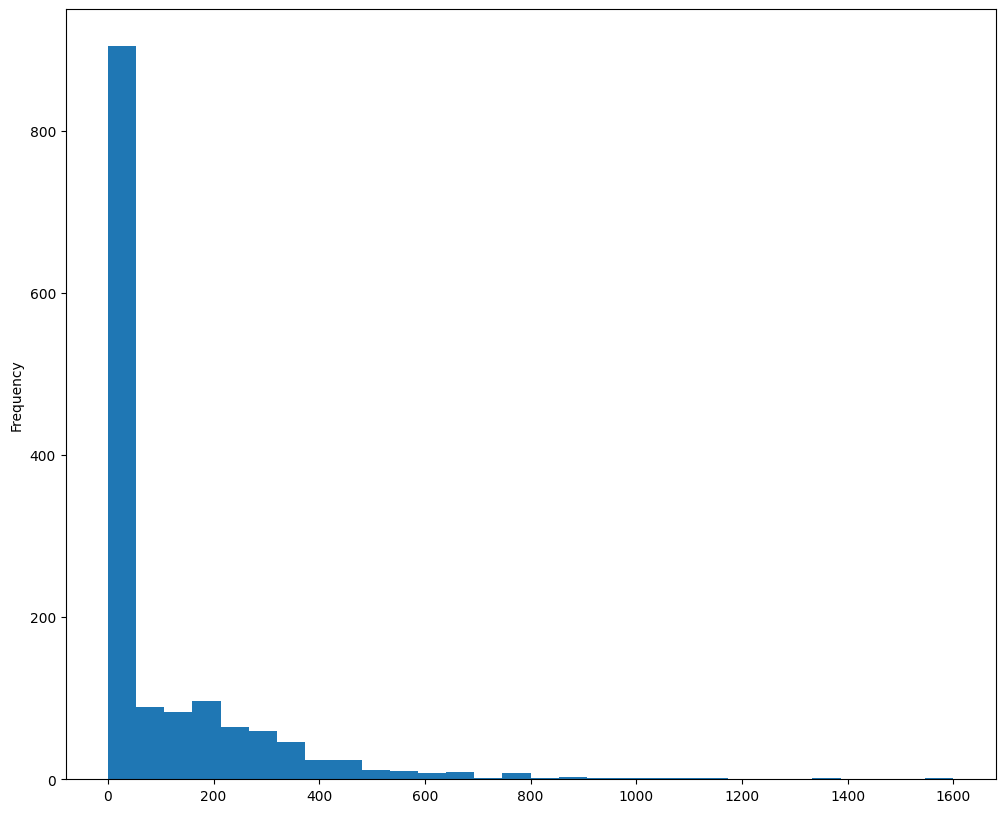

In [ ]:
ds['MasVnrArea'].plot(kind='hist', bins=30)

In [ ]:
# run the imputation when not making pipeline

ds['LotFrontage'] = ds['LotFrontage'].fillna(ds['LotFrontage'].median())
ds['MasVnrArea']  = ds['MasVnrArea'].fillna(ds['MasVnrArea'].median())
ds['GarageYrBlt'] = ds['GarageYrBlt'].fillna(ds['GarageYrBlt'].mean())
print(ds[continuous].isna().sum().sum())

0


###Encoding Features:

- First things first, we'll start with handling catrgorical features. So, how to find one?
  - This is where data dictionary comes handy. You can see that `MSSubClass` gas four classes: Fin, RFn, UnF, NA.
  - You will find similar features where the categorical values will be specified.

In [ ]:
ds[cat_to_con].isna().sum()

ExterQual          0
ExterCond          0
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
HeatingQC          0
KitchenQual        0
Functional         0
FireplaceQu      690
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
dtype: int64

In [ ]:
def pre_processing(ds, todrop, categorical, cat_to_con):
  #dropping
  ds = ds.drop(columns=todrop)

  #categorical
  logical_nans = ['Alley', 'Fence', 'MiscFeature', 'MasVnrType', 'GarageType', ]
  for col in logical_nans:
      ds[col] = ds[col].fillna('NA')
  ds['Electrical'] = ds['Electrical'].fillna(ds['Electrical'].value_counts().index[0])  # mode
  print("no. of nans in categorical cols:", ds[categorical].isna().sum().sum())


  #cat_to_con
  ds['FireplaceQu'] = ds['FireplaceQu'].fillna('NA')
  logical_nans = ['FireplaceQu', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
                  'BsmtFinType2', 'GarageFinish', 'GarageQual', 'GarageCond']
  for col in logical_nans:
      ds[col] = ds[col].fillna('NA')

  ds.drop(columns = ['PoolQC'], inplace=True)
  cat_to_con.remove('PoolQC')
  print("no. of nans in cat_to_con cols:",ds[cat_to_con].isna().sum().sum())

  #target_encoding
  target = 'SalePrice'
  for col in categorical:
      ds[col] = ds.groupby([col])[target].transform('mean')

  #label encoding
  grp1 = ['GarageQual', 'GarageCond', 'FireplaceQu', 'KitchenQual', 'HeatingQC', 'BsmtCond', 'BsmtQual', 'ExterCond', 'ExterQual']
  for col in grp1:
      ds[col] = ds[col].map({'TA': 3, 'Fa': 2, 'NA': 0, 'Gd': 4, 'Po': 1, 'Ex': 5})

  for col in ['BsmtFinType1', 'BsmtFinType2']:
      ds[col] = ds[col].map({'GLQ':6, 'ALQ':5, 'Unf':1, 'Rec':3, 'BLQ':4, 'NA':0, 'LwQ':2})

  ds['BsmtExposure'] = ds['BsmtExposure'].map({'No':1, 'Gd':4, 'Mn':2, 'Av':3, 'NA':0})
  ds['Functional'] = ds['Functional'].map({'Typ':7, 'Min1':6, 'Maj1':3, 'Min2':5, 'Mod':4, 'Maj2':2, 'Sev':1, 'Sal':0})
  ds['GarageFinish'] = ds['GarageFinish'].map({'RFn':2, 'Unf':1, 'Fin':3, 'NA':0})

  print("total nans in the dataframe:", ds.isna().sum().sum())

  return ds

In [ ]:
ds = pre_processing(ds, todrop, categorical, cat_to_con)

no. of nans in categorical cols: 0
no. of nans in cat_to_con cols: 0
total nans in the dataframe: 0


In [ ]:
ds.columns[ds.isna().sum()>0]

Index([], dtype='object')

###Scaling:

- We need to do scaling on this dataset, and the main factor to decide which method to choose! Standard Scaling or MinMax scaling? Or any other scaling method?

- The best method here would be Standard Scaling. The reason being; outliers will effect both min and max values; and doing minmax scaler will probably be a bad way.

- Another reason not to choose MinMax scaler is:
  - Say the min values in the dataset is `x` and max value is `y`.
  - Now, when in production, if any value comes out of range mentioned above (x and y); the value after scaling can go outside the range of `0` and `1`.

  - The output based on this can't be reliable, it may or may not be correct, because model has never seen this value before.

In [ ]:
# run the scaling when not making pipeline.
# All the viz will work on the standardized and imputed data

from sklearn.preprocessing import MinMaxScaler, StandardScaler

scaler = StandardScaler()
ds_scaled = scaler.fit_transform(ds)

- We also need to think of the baseline model. Whether we'll use linear regression, or decision trees, or random forests!?

- So, when these types of usecases are hosted as a competition on Kaggle, `Random Forests` and `GBDT` are seen to perform better comparitively. So, in this session, we'll also use these.

**Q. Do we need to scale the data for these models?**
- For these models, we dont need to scale the data. But, since we've anyway done that above for features, we won't be scaling the target variable.

- Again, all these steps depend on the baseline model that you choose.

##**Baseline Model:**

In [ ]:
X = ds_scaled[:, :-1]
y = ds['SalePrice'].values

kf = KFold(n_splits=5)


y_true, y_pred = np.array([]), np.array([])
for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    baseline_estimator = GradientBoostingRegressor(random_state=0)
    baseline_estimator.fit(X_train, y_train)
    y_true = np.append(y_true, y_test)
    y_pred = np.append(y_pred, baseline_estimator.predict(X_test))
print(mse(y_true, y_pred)**0.5)
print(mape(y_true, y_pred))

31179.820190011313
0.10166154434822022


- Let's try to plot results that will indicate how our model is predicting vs what are the actual values.

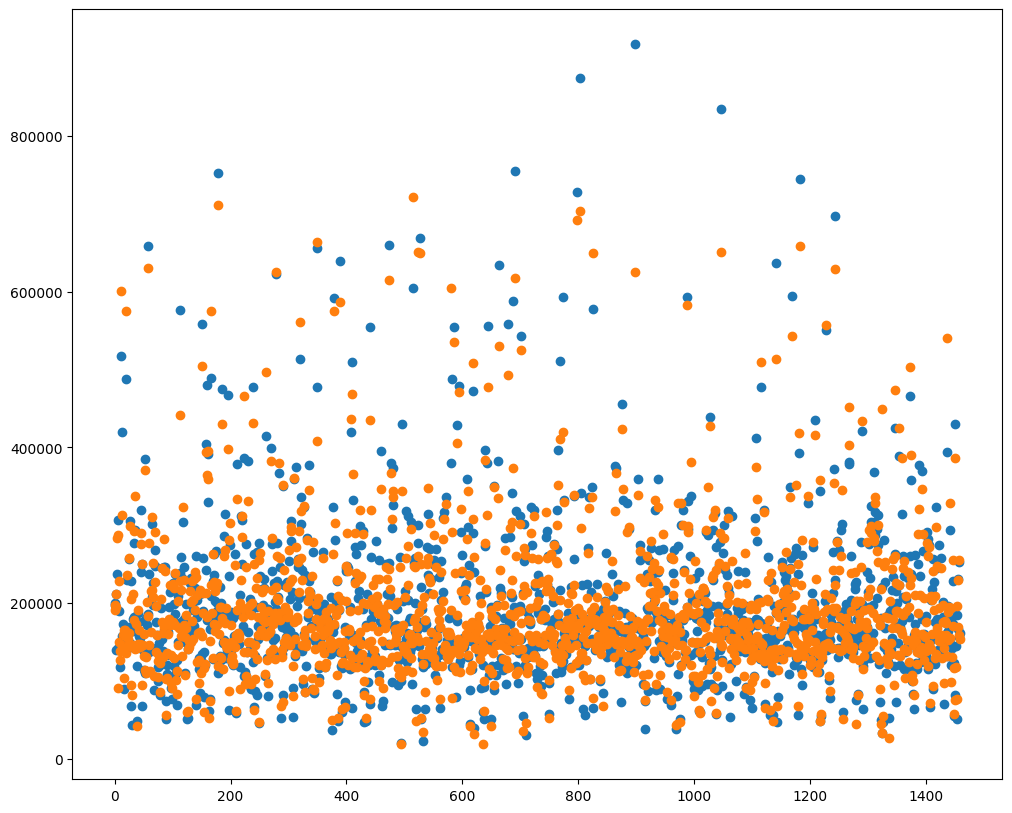

In [ ]:
plt.scatter(range(len(y_true)), y_true)
plt.scatter(range(len(y_true)), y_pred)

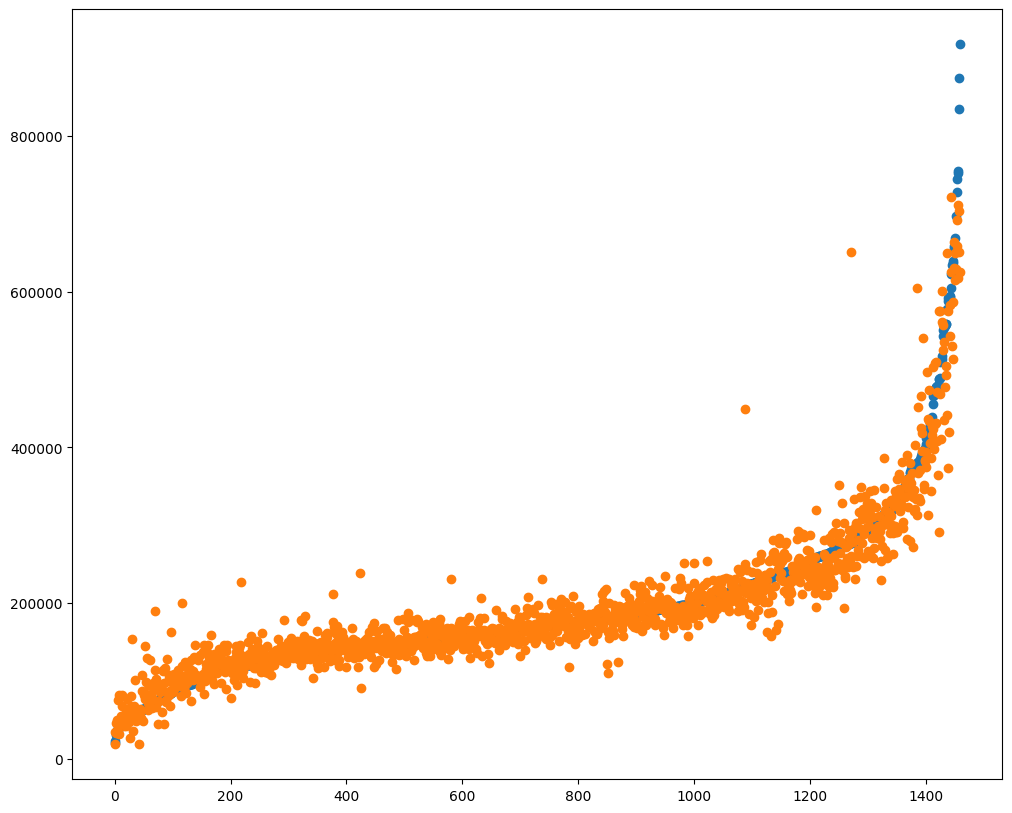

In [ ]:
# another way of visualising, range of predictions
plt.scatter(range(len(y_true)), sorted(y_true))
plt.scatter(range(len(y_true)), y_pred[np.argsort(y_true)])

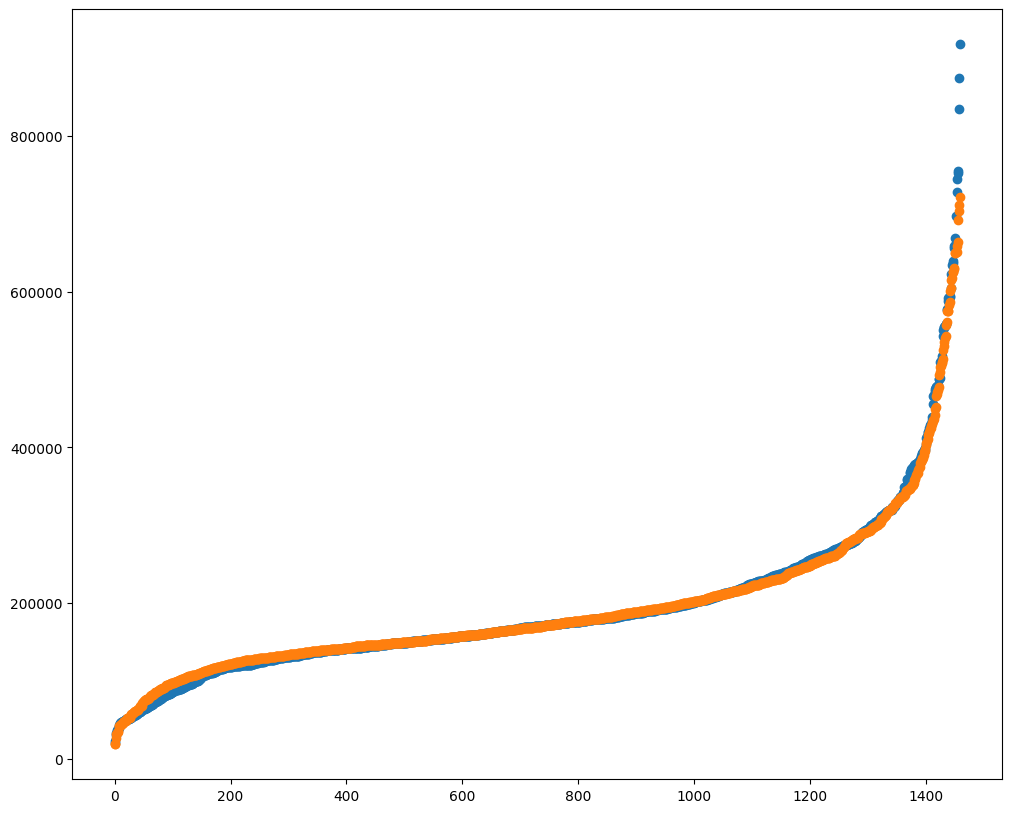

In [ ]:
# another way of visualising, scale of predictions
plt.scatter(range(len(y_true)), sorted(y_true))
plt.scatter(range(len(y_true)), sorted(y_pred))

- As you can see predictions are pretty much aligned with the actual values.

- But, if you observe the above scatter plot, you can see that the variance in the predictions is less than the variance in the actual values.

**Q. What does that mean?**
- It means that the model are making safe predictions by predicting in certain range. It does make some predictions far away, but the error rate increases there.

- There are more cheaper houses than the expensive ones, which makes sense because these might be the luxurious houees that are low in numbers comparitely.

- If you see, our basline model is making good predictions for cheap housed, where the error for predictions of the expensive houeses is more.

## Now that we've baseline model, can we apply some of ML-2 techniques that we learnt here?

### **Applying PCA:**

- The foremost thing that you'll ask yourself is that how many components to keep?
  - The answer for that is to do a trade-off between `dimensionality` and `% of information preserved`.

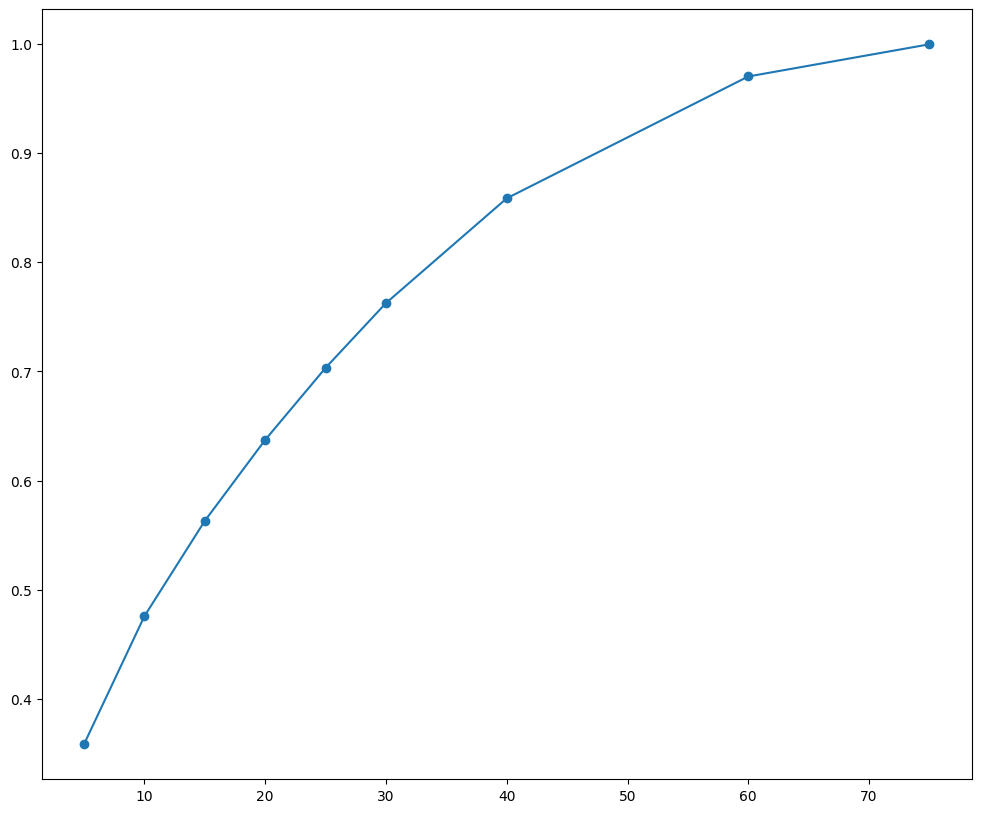

In [ ]:
from sklearn.decomposition import PCA
# is PCA effected by outliers/ can it overcome noise?
cs = [5, 10, 15, 20, 25, 30, 40, 60, 75]
info = []
for i in cs:
  pca = PCA(n_components=i)
  pca.fit(ds_scaled[:, :-1]) # do we need to scale before or after?
  info.append(pca.explained_variance_ratio_.sum())

plt.plot(cs, info, '-o')


- As you can see, we can keep `40` as number of components, because we can see a sharp elbow over there.
- So, after 40, the amount of information preserved is increasing by very small factor, which is oppposite before the number 40.


In [ ]:
pca = PCA(n_components=40)
Xpca = pca.fit_transform(ds_scaled[:, :-1])
y = ds['SalePrice']

kf = KFold(n_splits=5)

mses = []
mapes = []
n = 0

y_true, y_pred = np.array([]), np.array([])
for train_index, test_index in kf.split(X):
    X_train, X_test = Xpca[train_index], Xpca[test_index]
    y_train, y_test = y[train_index], y[test_index]
    baseline_estimator = GradientBoostingRegressor(random_state=0)
    baseline_estimator.fit(X_train, y_train)
    y_true = np.append(y_true, y_test)
    y_pred = np.append(y_pred, baseline_estimator.predict(X_test))

print(mse(y_true, y_pred)**0.5)
print(mape(y_true, y_pred))

36800.02120504329
0.11585410785843127


- Now, PCA made the rmse worse, and by this we got to know about what we think is not always true, and often it is not going to happen.


Let's go crazy:  `n_components` = 60

In [ ]:
pca = PCA(n_components=60)
Xpca = pca.fit_transform(ds_scaled[:, :-1])
y = ds['SalePrice']

kf = KFold(n_splits=5)

mses = []
mapes = []
n = 0

y_true, y_pred = np.array([]), np.array([])
for train_index, test_index in kf.split(X):
    X_train, X_test = Xpca[train_index], Xpca[test_index]
    y_train, y_test = y[train_index], y[test_index]
    baseline_estimator = GradientBoostingRegressor(random_state=0)
    baseline_estimator.fit(X_train, y_train)
    y_true = np.append(y_true, y_test)
    y_pred = np.append(y_pred, baseline_estimator.predict(X_test))

print(mse(y_true, y_pred)**0.5)
print(mape(y_true, y_pred))

# made even worse :(

37382.6579521133
0.11331657637648393


- One thing that we can try is we pick the top 20 important features(based on feature importance by baseline model) and apply PCA to the reamaining ones.

- ofcourse, this is trial and error technique, and this may or may not work.


### **Outlier Detection:**

- Let's first visualise the data in 2D using PCA and t-SNE both.

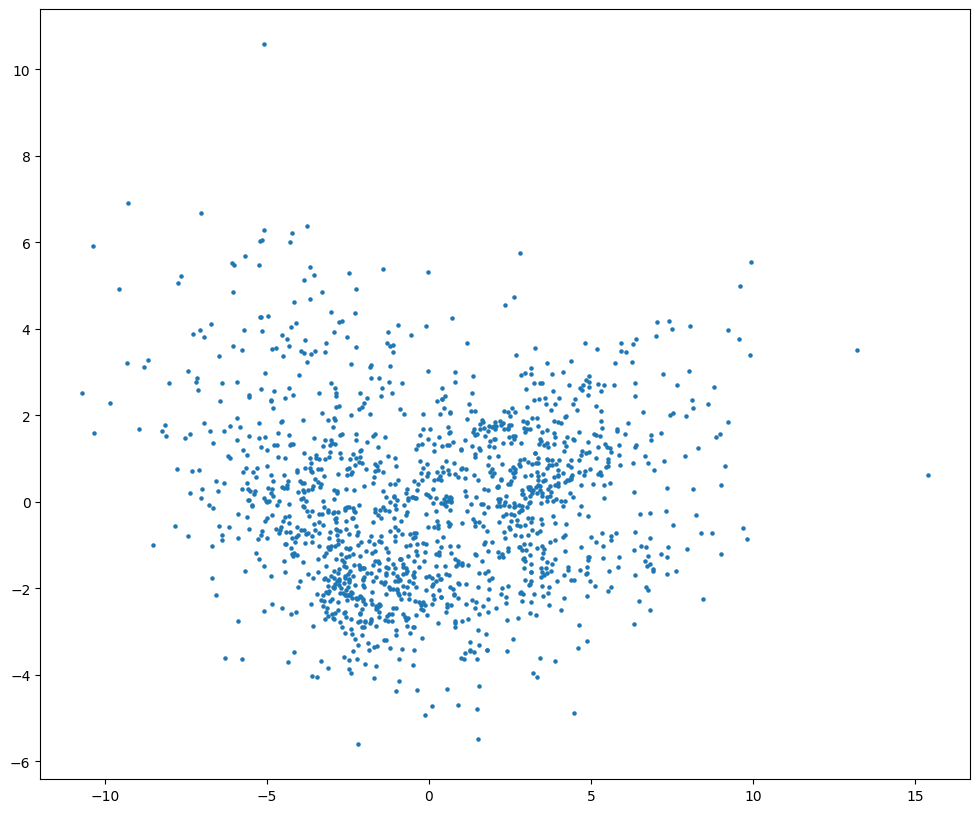

In [ ]:
pca = PCA(n_components=2)
vis = pca.fit_transform(ds_scaled[:, :-1])
plt.scatter(vis[:, 0], vis[:, 1], s = 5)

In [ ]:
# ANY OUTLIERS?
# WHAT ABOUT CLUSTERS? Maybe the model is good for certain house?

# TRY UMAP

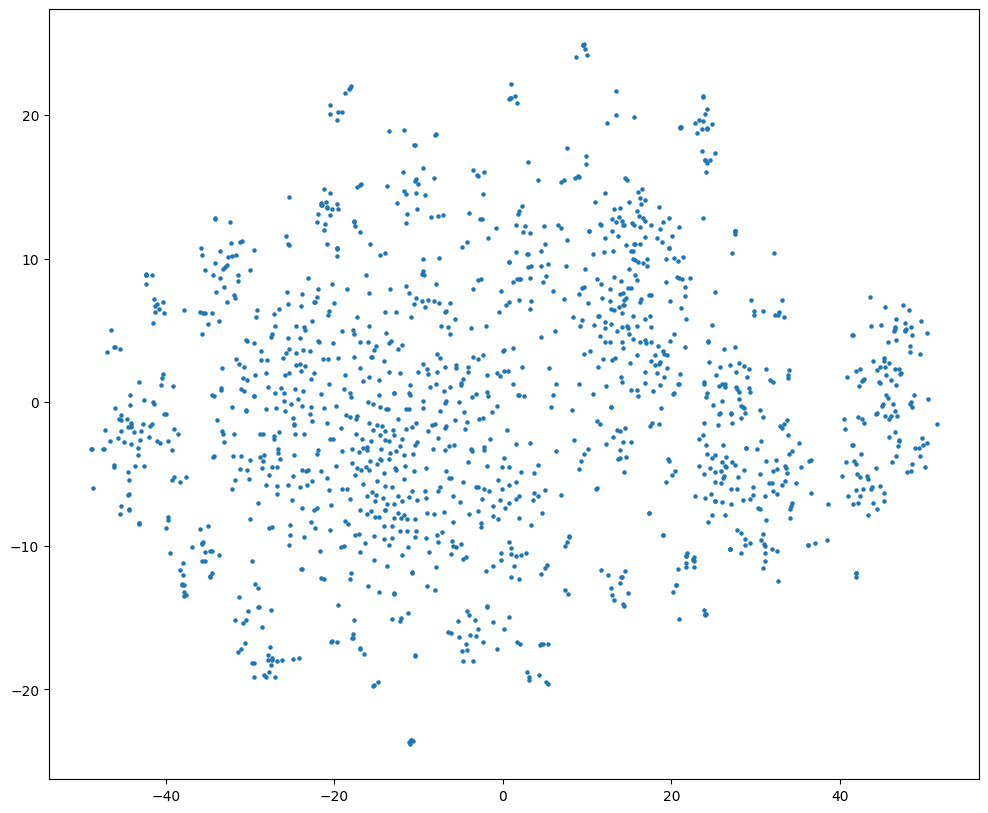

In [ ]:
from sklearn.manifold import TSNE

pca = TSNE(n_components=2, perplexity=50, random_state=0)
vis = pca.fit_transform(ds_scaled[:, :-1])
plt.scatter(vis[:,0], vis[:,1], s=5)

- As you can see, definitely, there are some outliers present in the data.

**Q. which outlier detection algorithm to pick?**

- Can we try Elliptic Envelope?
  - For sure, the answer is `no`. Because, if you see the scatter plot, the data is not distributed on `unimodal gaussian`.
  - You can still try, but most probably, it wont work.

- Let's try `Isolation Forests` and `Local Outlier Factor`.

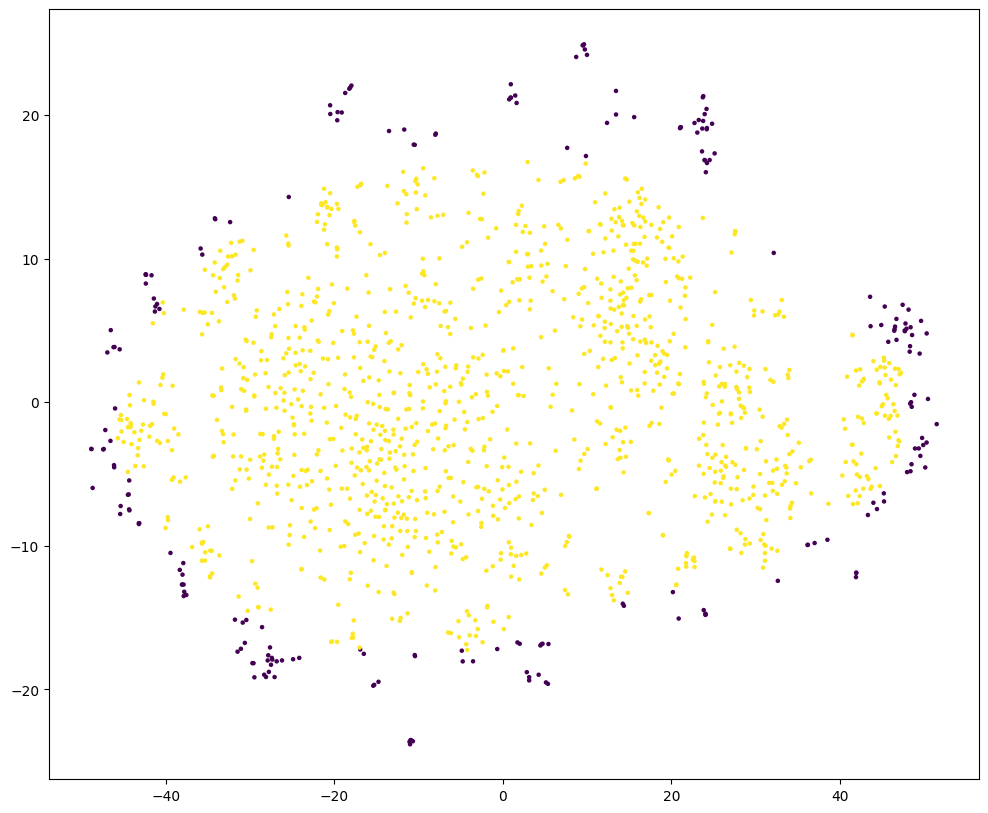

In [ ]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest

is_outlier = IsolationForest(contamination=0.15, random_state=0,
                            n_estimators=1000).fit_predict(vis)
plt.scatter(vis[:, 0], vis[:, 1], s=5, c=is_outlier)
plt.show()

- Isolation Forest is not able to detect outliers which are inside region of the scatter plot.

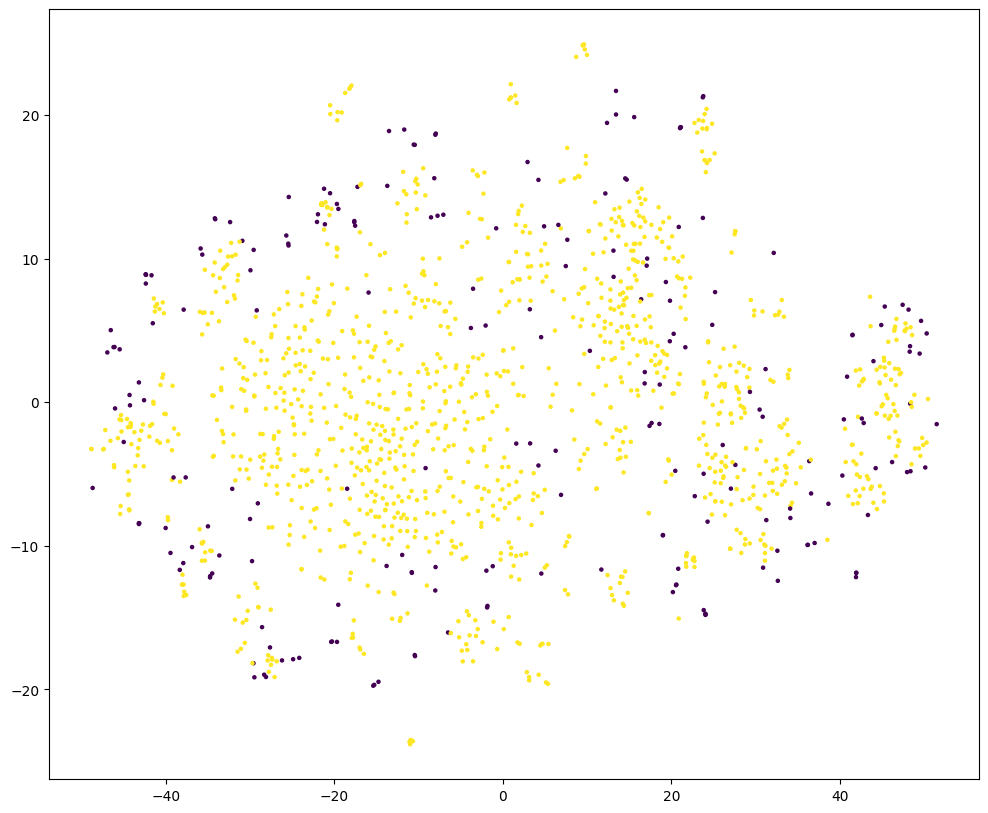

In [ ]:
is_outlier = LocalOutlierFactor(contamination=0.15, n_neighbors=5).fit_predict(vis)
plt.scatter(vis[:, 0], vis[:, 1], s=5, c=is_outlier)
plt.show()

- here, we have set 15% of the points as outliers, which is high, and we keep this number around 2% something.

- So, can we validate the outliers that we have detected in supervised setting?
  
  - One way to validate detected outliers is take `human input` from the domain expert, and let them make the call.
  
  - Another way is to fit the baseline model after removing the predicted outliers, and check the RMSE score

Let's now try soemthing interesting. Let's do clustering on this data, since we can see some clusters in the t-SNE plot

**Q. Why to do clustering for supervised learning?**

- WE can train different models for different clusters because in real life, houses of different types will have a different pattern / relation between features snd the price.

### **Clustering:**

**Q. Again, which clustering algorithm to use?**

- Looking at the data, we can say that K-Means probably wont work because of its fundamental nature of making equal sized clusters.

- Wheras, DBSCAN and Hierarchical can make different size and different density clusters. But these are offline models and we cant push them to production!!!

###K-Means:

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

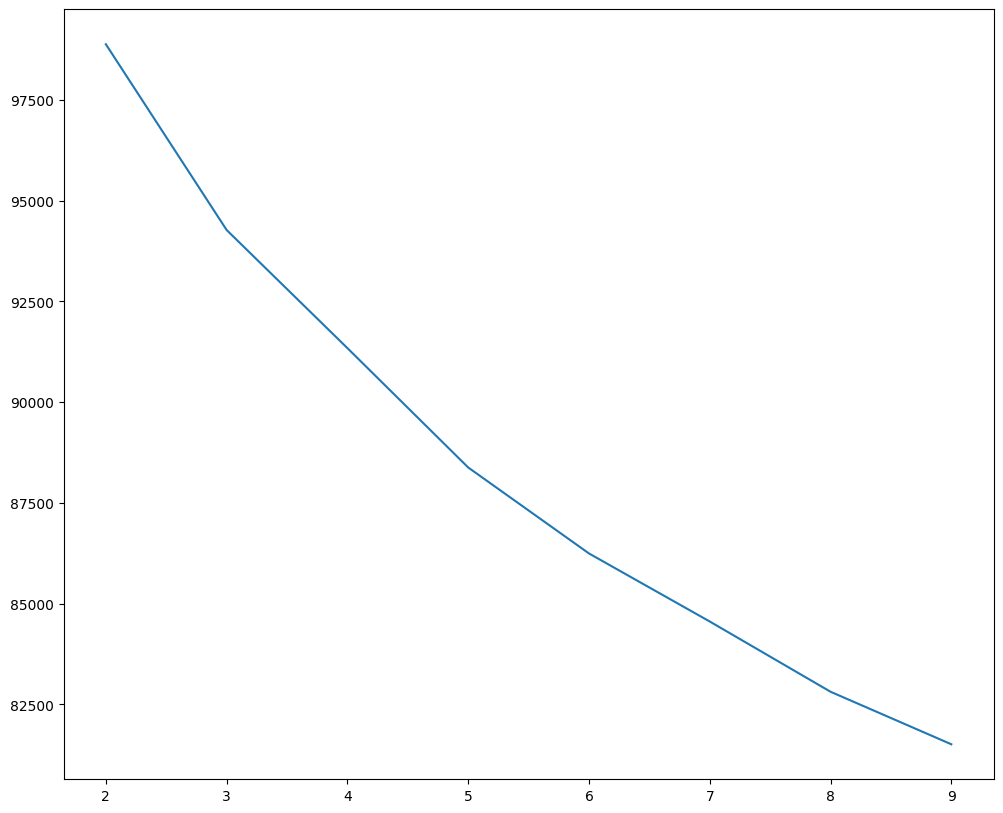

In [ ]:
from sklearn.cluster import KMeans

elbow = []
for k in range(2,10):
  kmeans = KMeans(n_clusters=k)
  kmeans.fit(ds_scaled[:, :-1])
  elbow.append(kmeans.inertia_)

plt.plot(range(2,10), elbow)

- You definitely cannot make a decision based on this, and this is what happends in real life! Let's try silhouette score.

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

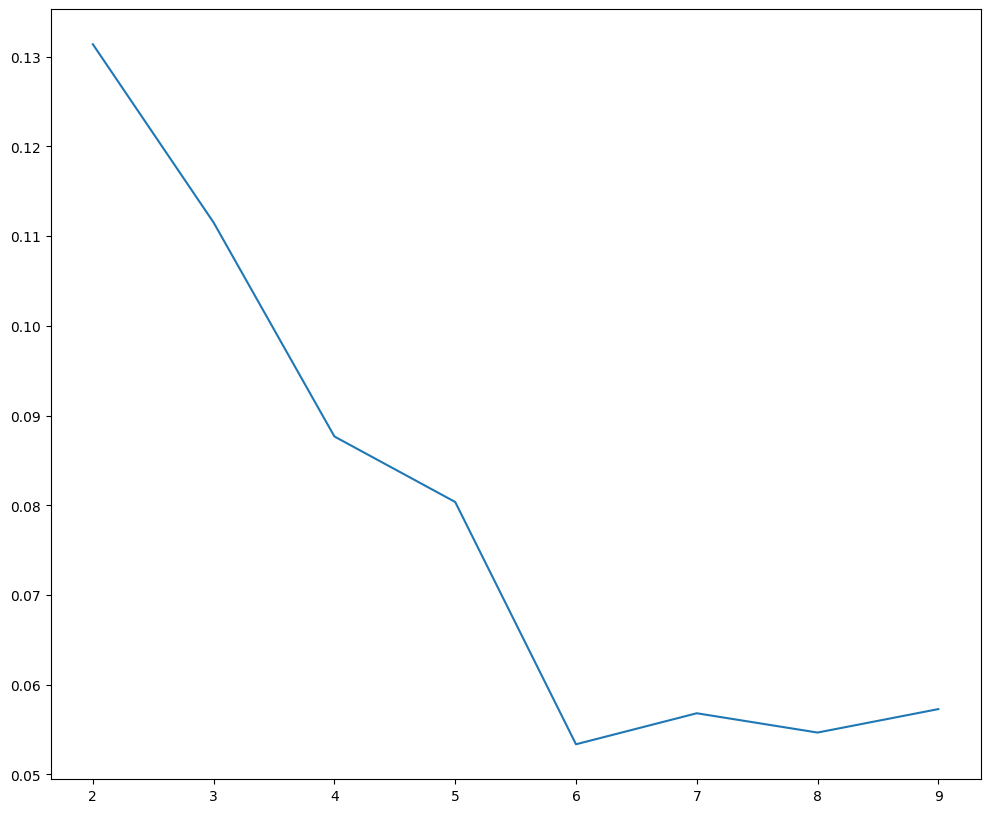

In [ ]:
from sklearn.metrics import silhouette_score

elbow = []
for k in range(2,10):
  kmeans = KMeans(n_clusters=k)
  kmeans.fit(ds_scaled[:, :-1])
  elbow.append(silhouette_score(ds_scaled[:, :-1], kmeans.labels_))

plt.plot(range(2,10), elbow)

- We can try with 4 or 7 cluster.

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


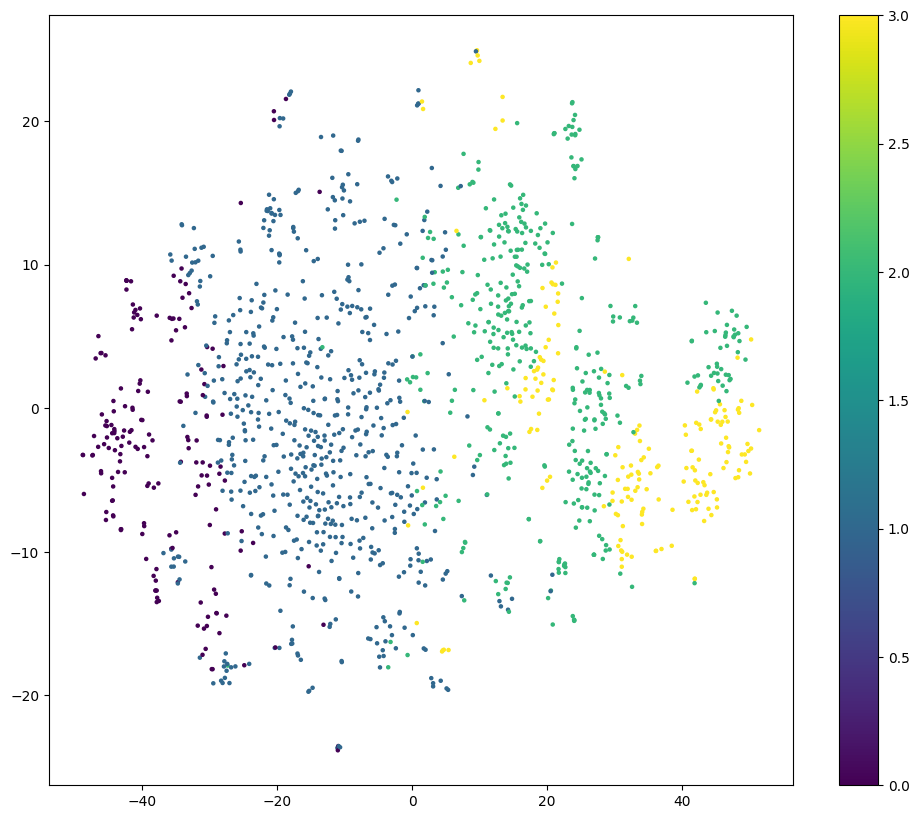

In [ ]:
kmeans = KMeans(n_clusters=4)
kmeans.fit(ds_scaled[:, :-1])
plt.scatter(vis[:, 0], vis[:, 1], s=5, c=kmeans.labels_)
plt.colorbar()

This doesn't look that useful

###Hierarchical Clustering:

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


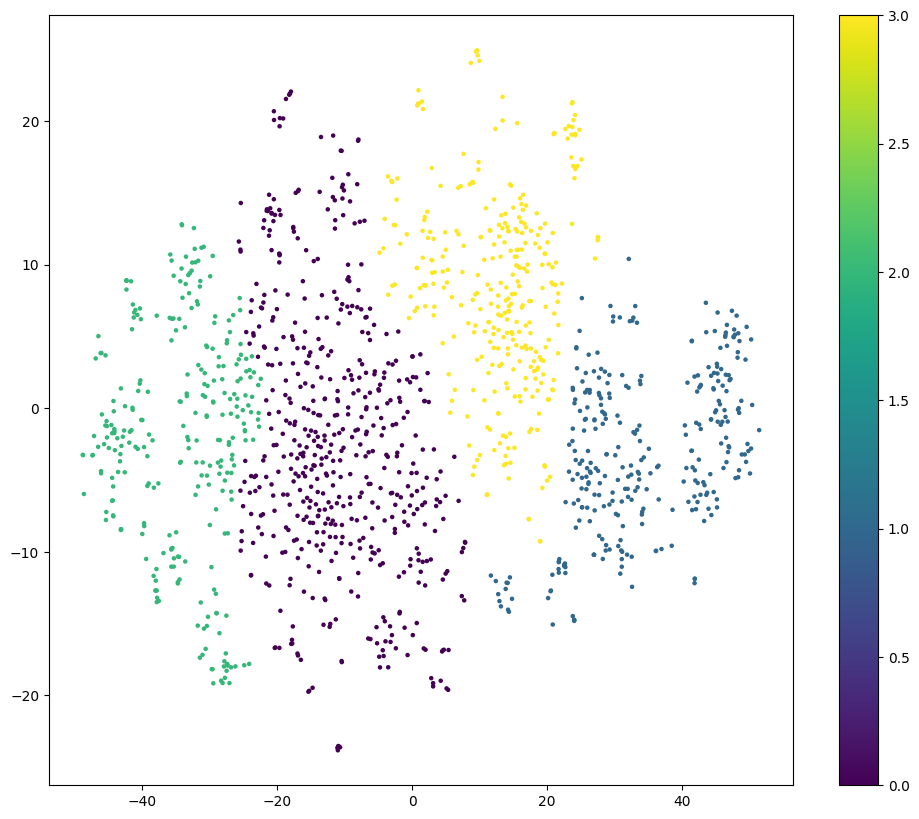

In [ ]:
from sklearn.cluster import AgglomerativeClustering
hierar = AgglomerativeClustering(n_clusters=4, affinity='euclidean', linkage='ward').fit(vis)
plt.scatter(vis[:, 0], vis[:, 1], s=5, c=hierar.labels_)
plt.colorbar()

- As you can see, it is still not the best clusters that you expected. So, we would have to try DBSCAN.

- We did not went with DBSCAN right away because it is an offline model.

###DBSCAN:

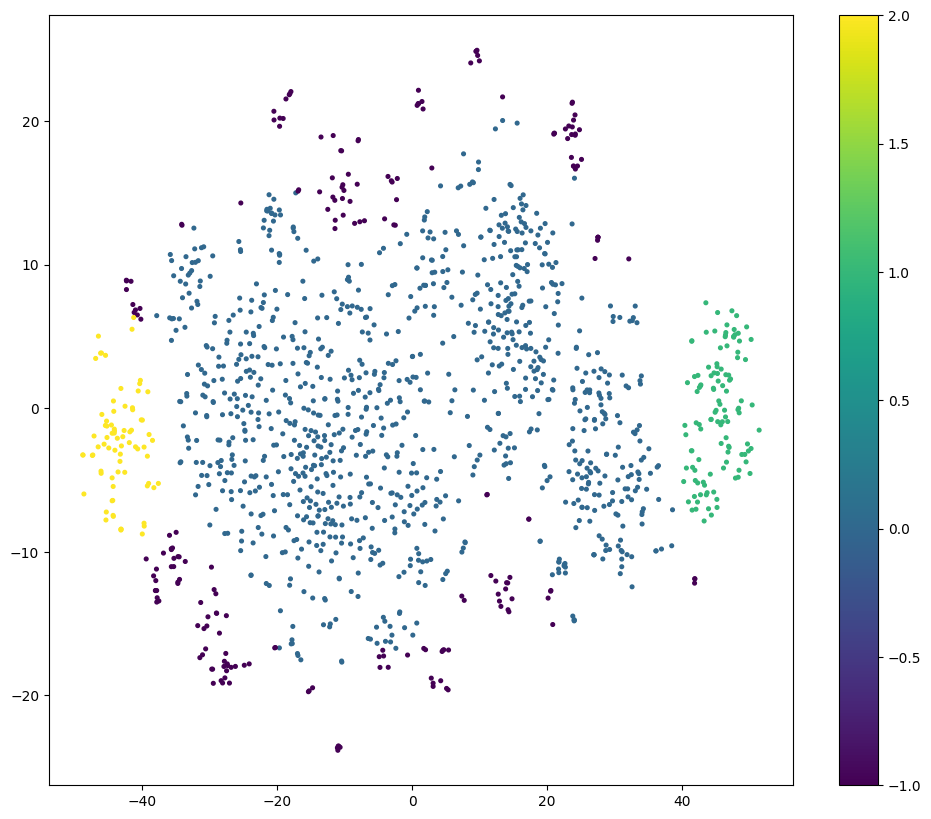

In [ ]:
from sklearn.cluster import DBSCAN
dbsc = DBSCAN(eps = 5.5, min_samples = 45).fit(vis)
plt.scatter(vis[:,0], vis[:,1], s=7, c=dbsc.labels_)
plt.colorbar()

- Again, this is not that we expected. DBSCAN has made some points on the outer region as outliers, and most of the points inside into a single cluster.

- This is the problem with DBSCAN. It is very hard to tune it.

>**CAN DO:**
> Try a bunch of different values for `eps` and `min_samples` so that learners can understand how it is tuned.

-1    490
 2    446
 0    191
 1    157
 3    114
 4     62
dtype: int64


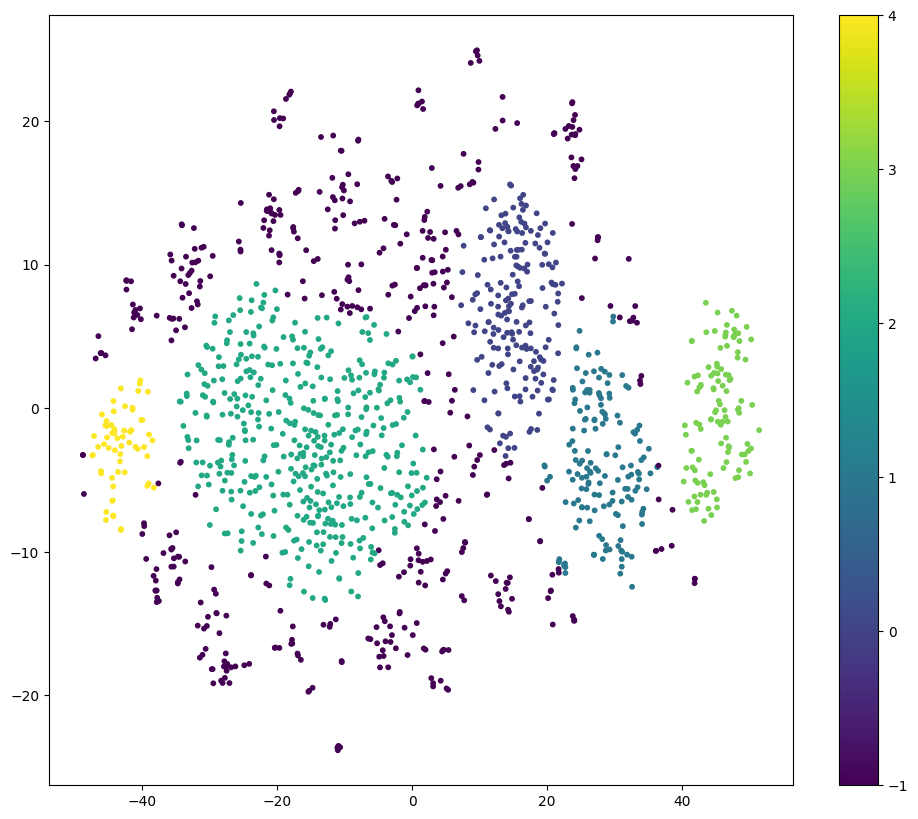

In [ ]:
from sklearn.cluster import DBSCAN
dbsc = DBSCAN(eps = 4.5, min_samples = 45).fit(vis)
plt.scatter(vis[:,0], vis[:,1], s=10, c=dbsc.labels_)
print(pd.Series(dbsc.labels_).value_counts())
plt.colorbar()

- Here, you can see how well separated outliers are, and how well clusters are formed compared to previous clustering algorithms.

- Now, for outliers you can take human input from experts for assigning outliers to clusters, or completely remove them.

##**EDA on Clusters:**

Let's start with finding global mean of target variable and means of local clusters.

In [ ]:
print("Global Mean: ", ds.SalePrice.mean())

Global Mean:  193784.76647260276


In [ ]:
ds.groupby(dbsc.labels_)['SalePrice'].mean()

-1    168775.860612
 0    226901.879319
 1    235204.859873
 2    153836.601794
 3    416137.815789
 4     63053.709677
Name: SalePrice, dtype: float64

- Cluster `4` (yellow) has the cheapest houses and cluster `3` (green) has the most expensive houses. In dbscan plot, you can see how far they are which depicts the correctness of the fact that they infact are very dissimilar in real world as well.

- Cluster `2` also has cheaper houses but it is also the closest to the global mean, which also be seen on the dbscan plot results.

- **QUESTION**: Now, here we are having 4 clusters, but say if there were 15 clusters, it would not make sense to train 15 different models for each cluster.

- What we can do is make a feature called `Cluster` that would have values 0 to 15, and then do target encoding and train a single model.

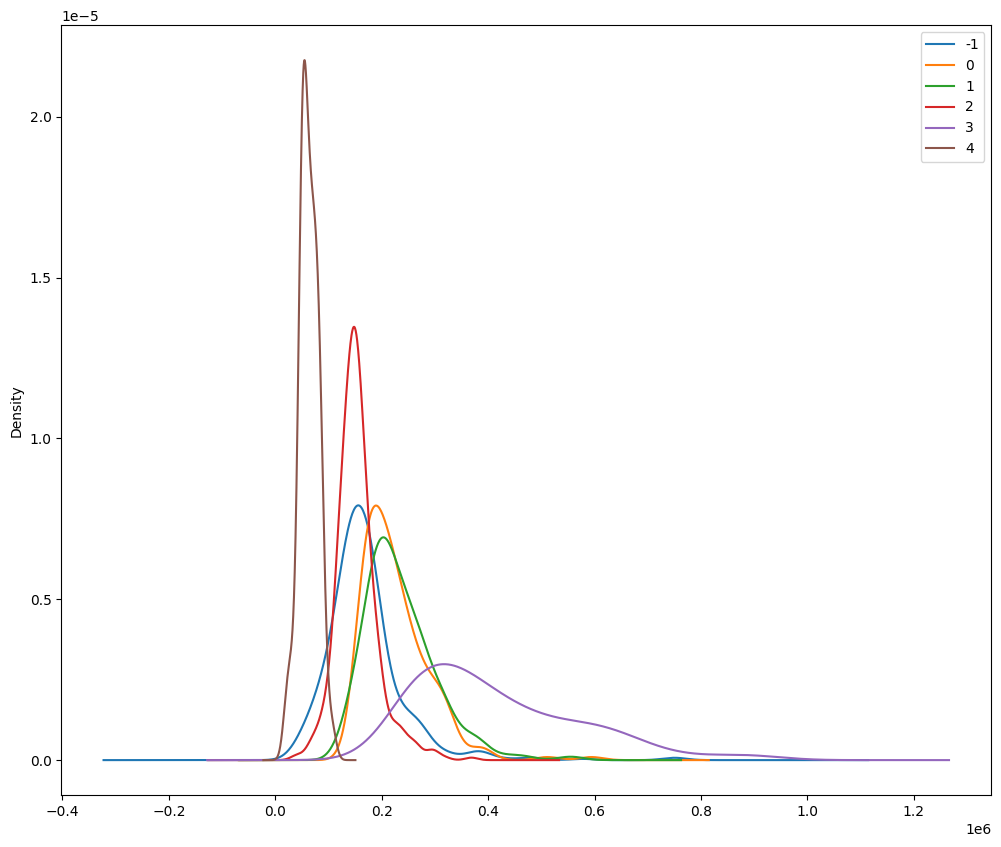

In [ ]:
ds.groupby(dbsc.labels_)['SalePrice'].plot(kind='kde')
plt.legend()

- As you can see, cluster `3` (expensive houses) has the highest variances, because of the fact that some of them might be of low price (but comparitively higher than other clusters), and some of them might be high.

- Whereas, cluster `4` has the least variance. From this we can say that it is easy to predict the price of cheap house and it is relatively harder to predict for expensive ones.


- Now, we have total of 79 features and we have total of 5 clusters. Doing EDA for each of them would be not feasible. What we can do is find out the most important features.

>**Instructor Notes:**
>
> Before running the cell below, re-run the cell where we trained `baseline_estimator` for the first time. below cell will give error because we had used PCA earlier.

In [ ]:
X = ds_scaled[:, :-1]
y = ds['SalePrice'].values

kf = KFold(n_splits=5)


y_true, y_pred = np.array([]), np.array([])
for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    baseline_estimator = GradientBoostingRegressor(random_state=0)
    baseline_estimator.fit(X_train, y_train)
    y_true = np.append(y_true, y_test)
    y_pred = np.append(y_pred, baseline_estimator.predict(X_test))
print(mse(y_true, y_pred)**0.5)
print(mape(y_true, y_pred))

31179.820190011313
0.10166154434822022


In [ ]:
fi = pd.DataFrame()
fi['features'] = ds.columns[:-1]
fi['importance'] = baseline_estimator.feature_importances_
fi.sort_values(by='importance', ascending=False)

,features,importance
76,SaleType,0.280922
16,OverallQual,0.257103
45,GrLivArea,0.117095
60,GarageCars,0.079479
11,Neighborhood,0.059458
...,...,...
64,PavedDrive,0.000000
47,BsmtHalfBath,0.000000
5,Alley,0.000000
48,FullBath,0.000000


>**CAN DO:**
>
> Explore data dictionary of the most important features, get domain knowledge

In [ ]:
ds.groupby(dbsc.labels_)['OverallQual', 'SaleType', 'GrLivArea', 'GarageCars',
                         'SalePrice'].mean()

<ipython-input-38-6efb1c5b44f6>:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  ds.groupby(dbsc.labels_)['OverallQual', 'SaleType', 'GrLivArea', 'GarageCars',


,OverallQual,SaleType,GrLivArea,GarageCars,SalePrice
-1,5.791837,177113.698754,1564.116327,1.742857,168775.860612
0,7.115183,175701.903688,1989.518325,2.246073,226901.879319
1,7.426752,174346.209297,1529.949045,2.305732,235204.859873
2,5.356502,174237.412949,1245.661435,1.452915,153836.601794
3,7.596491,406700.434426,1763.070175,2.517544,416137.815789
4,4.629032,179595.040273,1119.435484,0.000000,63053.709677


- again, for cluster `4` you can see `OverallQual` is least, it does not have any cars, and it has the least living area, because of which is the cheapest cluster.

- One interesting thing to note is to consider cluster `1` and cluster `3`. You will see all the important features very close in both the clusters, still the houeses in cluster `3` are very expensive than cluster `1`.
    >**CAN DO:**
    >
    > Explore these type of houses further

- In this type of scenarios, you will have to take a deep dive into remaining features as well.

**Q. We did not used target variable in t-SNE, nor in clustering. Is this really unsupervised learning?**

- It is not purely unsupervised technique because we used target encoded features. There is a leakage over here and because of it, this is known as `semi-supervised`.

- Also, the encoded values are highly correlated to the target variables.

**Q. We used DBCAN, but it cannot go into production. Any ideas on how to achieve similar results which can go into production?**

- We can use DBSCAN as a classification problem.
- We can set a manual rules using DBSCAN results, and make the points go the particular clusters based on some conditions.
- For example, if `OverallQual > 5`, the point should belong to cluster `2`. Ofcourse the rules wouldn't be this simple.  

>**THOUGHT:**
>
> Can we try GMM here?


😎😎😎😎😎😎😎😎

##**Baseline model without Outlier:**

In [ ]:
c = dbsc.labels_!=-1
X = ds_scaled[:, :-1][c]
y = ds['SalePrice'].values[c]
c = dbsc.labels_[dbsc.labels_!=-1]

kf = KFold(n_splits=5)

mses = []
mapes = []
n = 0

y_true, y_pred = np.array([]), np.array([])
for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    c_train, c_test = c[train_index], c[test_index]
    baseline_estimator = GradientBoostingRegressor(random_state=0)
    baseline_estimator.fit(X_train, y_train)
    y_true = np.append(y_true, y_test)
    y_pred = np.append(y_pred, baseline_estimator.predict(X_test))

print(mse(y_true, y_pred)**0.5,  mape(y_true, y_pred))

29794.485833082963 0.09516424937692104


Let's check the error for outliers, which we expect to be more than the inliers

### Baseline model on outliers

In [ ]:
outliers_X = ds_scaled[dbsc.labels_==-1][:, :-1]
outliers_y = ds[dbsc.labels_==-1]['SalePrice'].values
print(mse(outliers_y, baseline_estimator.predict(outliers_X))**0.5)
print(mape(outliers_y, baseline_estimator.predict(outliers_X)))

42759.577249892296
0.15385992443630264


### Target Transformation

- We applied basline model on data without outliers and got slight improvement. Can we improve further?

- We can try one more thing called `target transformation`.

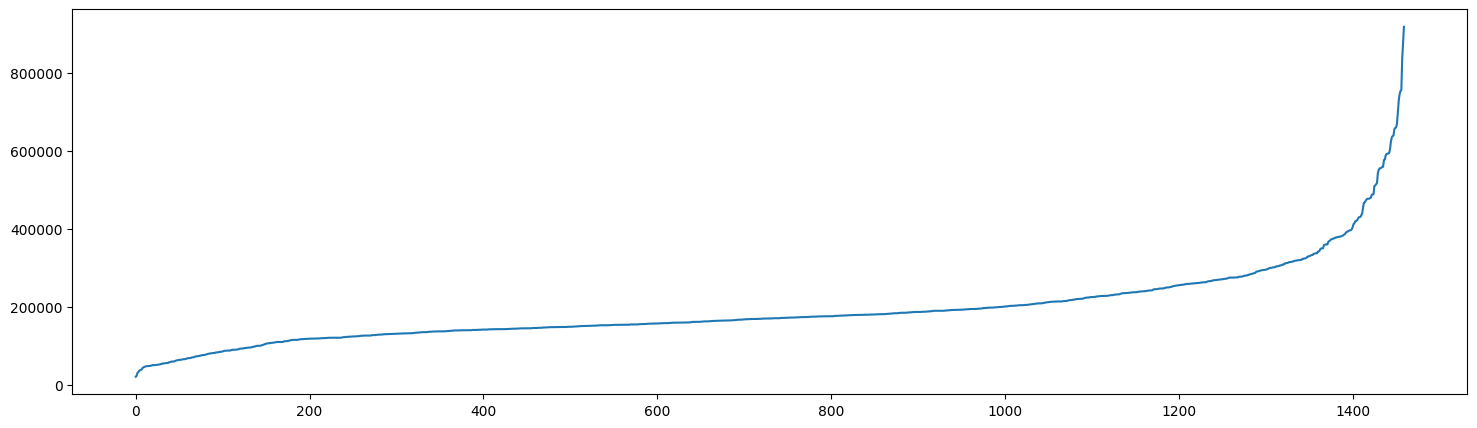

In [ ]:
plt.figure (figsize=(18, 5))
plt.plot(sorted(ds.SalePrice))

>**CAN WE SAY:**


- that training a `linear regression` model on this would not make sense. Here most of the houses are cheaper and then the prices are suddenly rising.

- That particular region of the distribution is very difficult to predict which leads to high errors.

- Using target transformation, we transform the target variable to be predicted easily

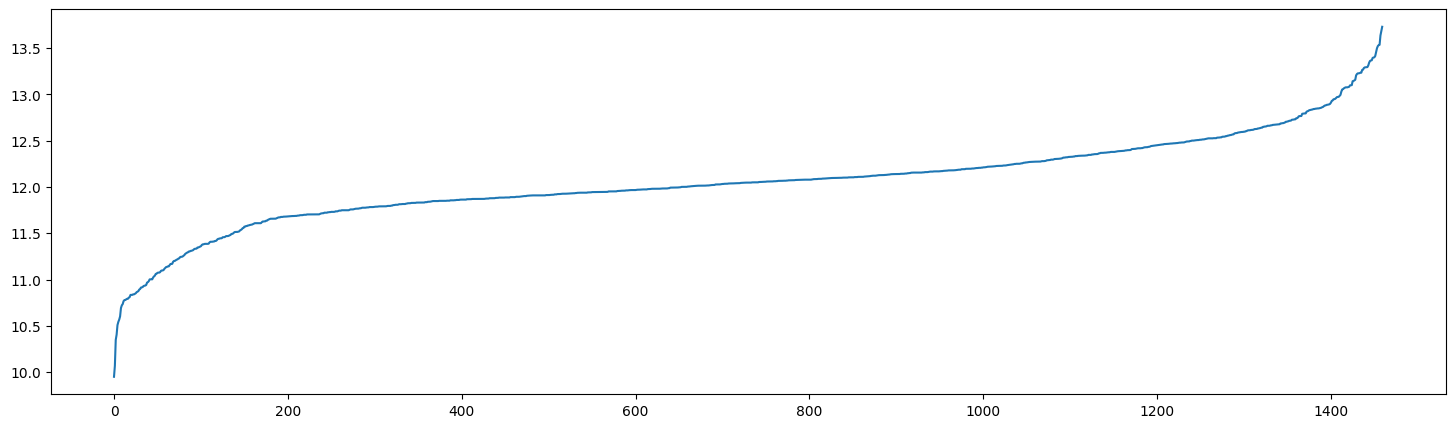

In [ ]:
plt.figure (figsize=(18, 5))
plt.plot(sorted(np.log(ds.SalePrice)))

- You can see, after transformation, there will be less errors in predcition compared to previously seen values.

In [ ]:
c = dbsc.labels_!=-1
X = ds_scaled[:, :-1][c]
y = np.log(ds['SalePrice'].values)[c]
c = dbsc.labels_[dbsc.labels_!=-1]

kf = KFold(n_splits=5)

mses = []
mapes = []
n = 0

y_true, y_pred = np.array([]), np.array([])
for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    c_train, c_test = c[train_index], c[test_index]
    baseline_estimator = GradientBoostingRegressor(random_state=0)
    baseline_estimator.fit(X_train, y_train)
    y_true = np.append(y_true, np.exp(y_test))
    y_pred = np.append(y_pred, np.exp(baseline_estimator.predict(X_test)))

print(mse(y_true, y_pred)**0.5, mape(y_true, y_pred))

30301.70649745071 0.08676519707625238


##**Baseline model (Cluster-wise):**

In [ ]:
c = dbsc.labels_!=-1
X = ds_scaled[:, :-1][c]
y = np.log(ds['SalePrice'].values)[c]
c = dbsc.labels_[dbsc.labels_!=-1]

kf = KFold(n_splits=5)

mses = []
mapes = []
n = 0
for cluster in range(5):
    y_true, y_pred = np.array([]), np.array([])
    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        c_train, c_test = c[train_index], c[test_index]
        estimator = GradientBoostingRegressor(random_state=0)
        estimator.fit(X_train, y_train)
        y_true = np.append(y_true, np.exp(y_test[c_test==cluster]))
        y_pred = np.append(y_pred, np.exp(estimator.predict(X_test[c_test==cluster])))
    mses.append(mse(y_true, y_pred)*len(y_true)**0.5)
    mapes.append(mape(y_true, y_pred)*len(y_true))
    n+=len(y_true)

    print(cluster, 'mse :', mse(y_true, y_pred)**0.5, 'mape:',mape(y_true, y_pred))

print(sum(mses)/n, sum(mapes)/n)

0 mse : 23716.875434911333 mape: 0.06605155776012943
1 mse : 21606.10212451004 mape: 0.06197832665866594
2 mse : 18087.289647535777 mape: 0.09029710251612613
3 mse : 69770.58287142588 mape: 0.1086240036293274
4 mse : 12093.22206602421 mape: 0.14774439049087024
75937007.43871133 0.08676519707625238


**Q. What can we infer from this numbers?**
- Can we say that model is making worst predictions for cluster `3` and the best for cluster `4` just based on RMSE?
- Can we even compare clusters just based on RMSE values?

- The important thing here is the `mape` factor. If you see mape for cluster `4` is highest and cluster `3` has lower mape than `4`.

- So, $MSE = ∑ \large\frac{( y - ̂y)^2}{n}$

- $MAPE = \frac{1}{n}\large\frac{| y - ̂y |}{y}$

- For `cluster 4` MSE has an error of 12k dollars, while `cluster 3` has an error of 70k dollars. But with respect to what?

- So in cluster 4, there is an error of 20k dollars with an avg value of 60k dollars.

- While in cluster 3, there is an error of 70k dollars with respect to a avg value of 410k dollars. This is what `mape` score represents.  Hence, relative scores are also important and it is important to consider mape scores as well.

##**Problem with Clustering:**

- We initially thought that finding clusters in the data would help us achieve better results. But, there was no significant improvement there. Why did that happended?

- So, when we train the model on whole dataset, there is some training accuracy and some testing accuracy.

- But, when we train model on a piece of cluster, only training score tends to improve because of less number of points. Because of which the model overfits on that particular cluster.

- And, this does not guarantee that the testing accuracy will be better.

- Is there any solution to this?

- Earlier we saw that cluster `0` and `1` had almost same average target variables. We can merge those clusters into one.

###**Merging Clusters:**

In [ ]:
mses = []
mapes = []
n = 0

dbsc_merged = pd.Series(dbsc.labels_).copy()
dbsc_merged.loc[dbsc_merged == 0] = 2
dbsc_merged.loc[dbsc_merged == 1] = 2

estimators = [GradientBoostingRegressor(n_estimators=50, learning_rate=0.6,max_depth=1, random_state=0)]
final_estimator = LinearRegression()

for cluster in range(2,5):
    X = ds_scaled[dbsc_merged==cluster][:, :-1]
    y = np.log(ds['SalePrice'].values)[dbsc_merged==cluster]
    estimator = GradientBoostingRegressor(random_state=0)
    # estimator = stacking(estimators, final_estimator)
    kf = KFold(n_splits=5)

    y_true, y_pred = np.array([]), np.array([])
    _ = []
    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        estimator.fit(X_train, y_train)
        _.append(mse(np.exp(y_train), np.exp(estimator.predict(X_train))))
        y_true = np.append(y_true, np.exp(y_test))
        y_pred = np.append(y_pred, np.exp(estimator.predict(X_test)))
    print(sum(_)/len(_))
    mses.append(mse(y_true, y_pred)*len(y_true)**0.5)
    mapes.append(mape(y_true, y_pred)*len(y_true))
    n+=len(y_true)

    print(cluster, 'mse :', mse(y_true, y_pred)**0.5, 'mape:',mape(y_true, y_pred))

print(sum(mses)/n, sum(mapes)/n)

99382396.22868016
2 mse : 21186.911841693636 mape: 0.07859122826426093
29355657.71088885
3 mse : 73239.78499901223 mape: 0.11229724808431502
105888.25014402505
4 mse : 13258.2498370825 mape: 0.18427199950034548
73510666.6577067 0.08930740772418197


##**Architecture:**

- What we can do further is that train a customer GMM model on the detected outliers, for which we will get some probabilities.

- We will use the clusters with these probabilities to gain the final output to classify the outlier.

- Also, we can train a meta model after clustering which consists of Random forest, gradient boosting and linear regression.

<img src='https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/028/139/original/Architecture.png?1678872249'>

- Again, this architecture should have better results, if not then go with the simpler one.

In [ ]:
gaussians = {}
for cluster in range(2, 5):
    gaussians[cluster] = (
        vis[dbsc_merged==cluster].mean(axis=0),
        np.cov(vis[dbsc_merged==cluster].T)
    )

In [ ]:
gaussians

{2: (array([ 0.36283407, -0.37829328], dtype=float32),
  array([[405.41755354,  17.94846253],
         [ 17.94846253,  39.47637031]])),
 3: (array([45.406834  , -0.36098555], dtype=float32),
  array([[ 7.44999074,  3.09177066],
         [ 3.09177066, 16.43202778]])),
 4: (array([-43.129852 ,  -2.8318782], dtype=float32),
  array([[5.7127097 , 1.21765278],
         [1.21765278, 7.00371191]]))}

In [ ]:
from scipy.stats import multivariate_normal as mvn

def gmm_inference(x):
    # TODO: Can speed this up, how???? Vecotrize this
    probs = np.array([mvn(*gaussians[2]).pdf(x), mvn(*gaussians[3]).pdf(x), mvn(*gaussians[4]).pdf(x)]) # Probability density function.
    probs = probs / sum(probs)
    return probs

In [ ]:
gmm_inference(vis[0])

array([1.00000000e+000, 2.42812179e-033, 1.60219679e-124])

In [ ]:
gmm_inference(vis[dbsc.labels_==4][-1])

array([8.46153918e-003, 3.43148740e-260, 9.91538461e-001])

### Ensemble

**CAN DO**:
- stacking

In [ ]:
estimators = [
    ('rf', RandomForestRegressor(n_estimators=50,random_state=42)),
    ('gbdt', GradientBoostingRegressor(n_estimators=50, learning_rate=0.6,max_depth=1, random_state=0)),
    ('knn', KNeighborsRegressor(n_neighbors=7))
]
final_estimator = LinearRegression()

In [ ]:
#custom stacking
class stacking(BaseEstimator):
  def __init__(self, estimators, final_estimator):
      self.estimators = estimators
      self.final_estimator = final_estimator


  def fit(self, X, y=None):
        for estimator in self.estimators:
            estimator[1].fit(X, y)

        pred_features = np.array([estimator[1].predict(X) for estimator in self.estimators]).T
        self.final_estimator.fit(pred_features, y)

  def predict(self, X):
        pred_features = np.array([estimator[1].predict(X) for estimator in self.estimators]).T
        return self.final_estimator.predict(pred_features)

  def score(self, X, y):
        pred_features = np.array([estimator[1].predict(X) for estimator in self.estimators]).T
        return self.final_estimator.score(pred_features, y)


In [ ]:
c = dbsc.labels_!=-1
X = ds_scaled[:, :-1][c]
y = np.log(ds['SalePrice'].values)[c]
c = dbsc.labels_[dbsc.labels_!=-1]

kf = KFold(n_splits=5)

mses = []
mapes = []
n = 0

y_true, y_pred = np.array([]), np.array([])
for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    c_train, c_test = c[train_index], c[test_index]
    # baseline_estimator = GradientBoostingRegressor(random_state=0)
    baeline_estimator = StackingRegressor(estimators, final_estimator)
    baseline_estimator.fit(X_train, y_train)
    y_true = np.append(y_true, np.exp(y_test))
    y_pred = np.append(y_pred, np.exp(baseline_estimator.predict(X_test)))

print(mse(y_true, y_pred)**0.5, mape(y_true, y_pred))

30301.70649745071 0.08676519707625238
